# Fashion MNIST 图像分类实验

## 一、实验背景

Fashion MNIST 是由 Zalando Research 发布的服饰图像分类数据集，相比传统 MNIST 手写数字数据集，Fashion MNIST 更具挑战性。

数据集包含：

- 训练集：60000张图片
- 测试集：10000张图片
- 图像大小：28×28
- 类别数量：10类

| Label | Category    |
| ----- | ----------- |
| 0     | T-shirt/top |
| 1     | Trouser     |
| 2     | Pullover    |
| 3     | Dress       |
| 4     | Coat        |
| 5     | Sandal      |
| 6     | Shirt       |
| 7     | Sneaker     |
| 8     | Bag         |
| 9     | Ankle boot  |

### 实验目标

本实验将尝试多种机器学习与深度学习方法：

1. Logistic Regression
2. KNN
3. Decision Tree
4. Random Forest
5. SVM
6. CNN（TensorFlow）

并从多个评价指标进行比较：

- Accuracy
- Precision
- Recall
- F1-score
- Training Time

最终分析不同算法的优缺点。

In [1]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

import time

from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize']=(8,6)

plt.rcParams['font.sans-serif'] = ['SimHei']   # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False     # 让负号正常显示

## 二、数据集介绍与处理

Fashion MNIST是一个灰度图像分类数据集。

数据集包含：

- 训练集：60000张
- 测试集：10000张

具有以下特点：

- 图像大小：28 × 28

- 共10个类别

- 相比MNIST数字识别数据集，Fashion MNIST具有更复杂的图像结构和更高的分类难度，因此被广泛用于机器学习和深度学习算法测试。

### 2.1 数据集获取与构建

导入必要处理库之后，下面为加载数据集并保存到当前工作目录下

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist", output_dir='./data')

print("Path to dataset files:", path)

Path to dataset files: ./data


我们查看一下数据集的目录结构，便于后面进行数据预处理操作

In [3]:
for root, dirs, files in os.walk('./data'):
    print(root)
    for file in files:
        print("   ", file)

./data
    fashion-mnist_test.csv
    fashion-mnist_train.csv
    t10k-images-idx3-ubyte
    t10k-labels-idx1-ubyte
    train-images-idx3-ubyte
    train-labels-idx1-ubyte
./data\.complete
./data\.complete\datasets
./data\.complete\datasets\zalando-research
./data\.complete\datasets\zalando-research\fashionmnist
./data\.complete\datasets\zalando-research\fashionmnist\4
    bundle.complete


从数据集结构可以看出该数据集由两种文件组成，一个是csv格式的文件，一个是ubyte二进制文件，它们区别如下：

| 特点             | ubyte（原始）    | csv（文本）          |
| ---------------- | ---------------- | -------------------- |
| **格式**         | 二进制           | 文本表格             |
| **能否直接打开** | 不能（乱码）     | 能（Excel / 记事本） |
| **文件大小**     | 小               | 大（约 10 倍）       |
| **读取速度**     | 快               | 较慢                 |
| **使用难度**     | 高（需解析）     | 低（直接读）         |
| **内容**         | 完全一样         | 完全一样             |

由于数据集大小较小（约70M）,同时为了更好的可视化，在后续数据处理我们采用csv文件。

让我们进入数据集介绍与构建部分。

为了使用数据集，我们先读取csv文件，查看一下整体结构和部分样本，以便了解其构成然后进行操作。

In [4]:
train_df = pd.read_csv('./data/fashion-mnist_train.csv')
test_df = pd.read_csv('./data/fashion-mnist_test.csv')

print("训练集形状:", train_df.shape)
print("测试集形状:", test_df.shape)

训练集形状: (60000, 785)
测试集形状: (10000, 785)


In [5]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


我们展示了前5行样本，根据MINIST数据集介绍，我们能够了解到

- 共785列
- 第一列为类别标签(label)
- 后784列为图像像素值
- 每张图像尺寸为28×28

因此可以将784个像素重新恢复为二维图像。

了解了结构，接下来就可以进行数据第一部处理，我们要先重建样本，形成数据集的格式，第一步是分离特征和标签

In [6]:
X_train = train_df.iloc[:,1:].values
y_train = train_df.iloc[:,0].values

X_test = test_df.iloc[:,1:].values
y_test = test_df.iloc[:,0].values

print("train data shape:", X_train.shape)
print("train labels shape:", y_train.shape)

print("test data shape:", X_test.shape)
print("test labels shape:", y_test.shape)

train data shape: (60000, 784)
train labels shape: (60000,)
test data shape: (10000, 784)
test labels shape: (10000,)


特征和标签已经分离，下一步就是重建图像，让我们能**直观看到图片**

In [7]:
X_train_img = X_train.reshape(-1,28,28)
X_test_img = X_test.reshape(-1,28,28)

print("train images shape:", X_train_img.shape)
print("test images shape:", X_test_img.shape)

train images shape: (60000, 28, 28)
test images shape: (10000, 28, 28)


由上面的输出可以看出，数据重建已经完成，接下来可以查看一些数据集的特点

### 2.2 数据集探索

#### 2.2.1 样本展示

在建立模型之前，首先观察原始样本。

这样能够帮助我们：

- 了解数据特征
- 判断分类难度
- 预测模型表现

下面随机展示25张训练集图像。

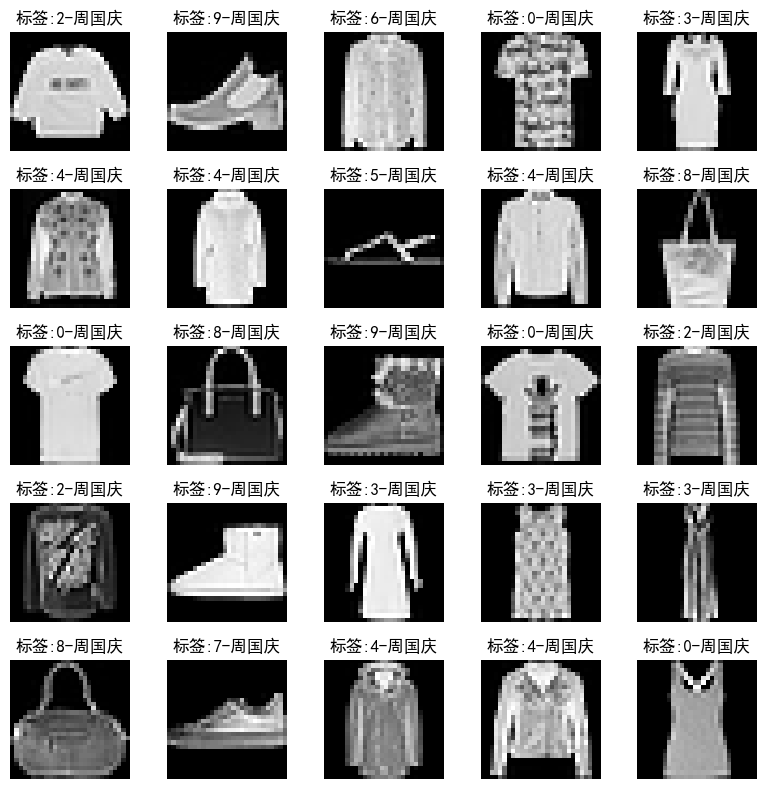

In [8]:
fig, axes = plt.subplots(5,5,figsize=(8,8))

for i, ax in enumerate(axes.flat):

    ax.imshow(
        X_train_img[i],
        cmap='gray'
    )

    ax.set_title(f"标签:{y_train[i]}-周国庆")
    ax.axis('off')

plt.tight_layout()
plt.show()

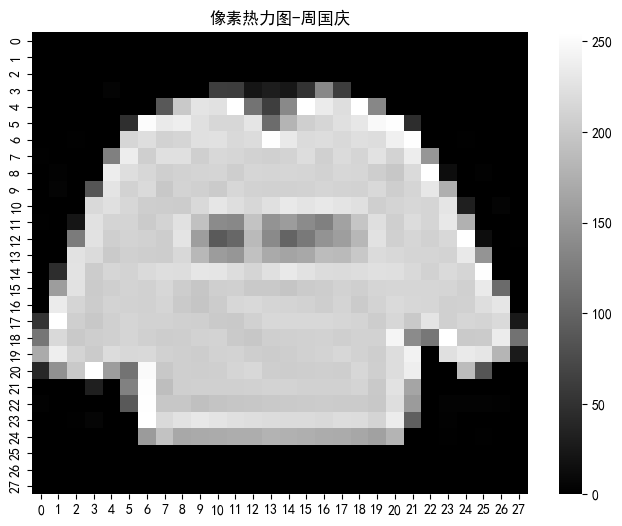

In [9]:
sample = X_train_img[0]

sns.heatmap(sample,cmap='gray')
plt.title("像素热力图-周国庆")
plt.show()

从随机样本中可以发现：

**1. 图像分辨率较低**

所有图像仅有28×28像素，大量细节信息已经丢失，因此模型需要从有限像素信息中提取有效特征。

**2. 不同类别差异明显**

例如：

- Bag
- Sneaker
- Ankle Boot

具有独特轮廓，预计较容易分类。

**3. 部分类别高度相似**

例如：

- Shirt
- Coat
- Pullover

三者均表现为上衣结构，预计后续分类器容易发生混淆。

**4. 图像背景简单**

大部分背景接近纯黑，这有利于模型提取前景目标特征。

#### 2.2.2 类别分布

机器学习中一个重要问题是类别不平衡，如果某些类别样本远多于其他类别，模型可能产生偏向。

因此首先查看各类别样本数量。

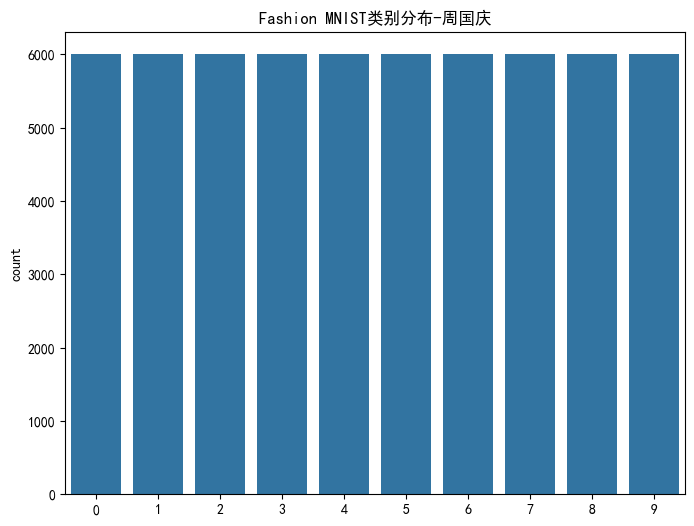

In [10]:
sns.countplot(x=y_train)
plt.title("Fashion MNIST类别分布-周国庆")
plt.show()

**类别分布分析**

观察统计图可以发现：

10个类别样本数量完全一致，每个类别均包含6000张训练图像。

因此：

- 数据集完全均衡
- 不存在类别偏置
- Accuracy指标具有较高可信度

由以上结论，则本实验无需进行：

- 欠采样
- 过采样
- SMOTE

等额外处理。

#### 2.2.3 像素值分析

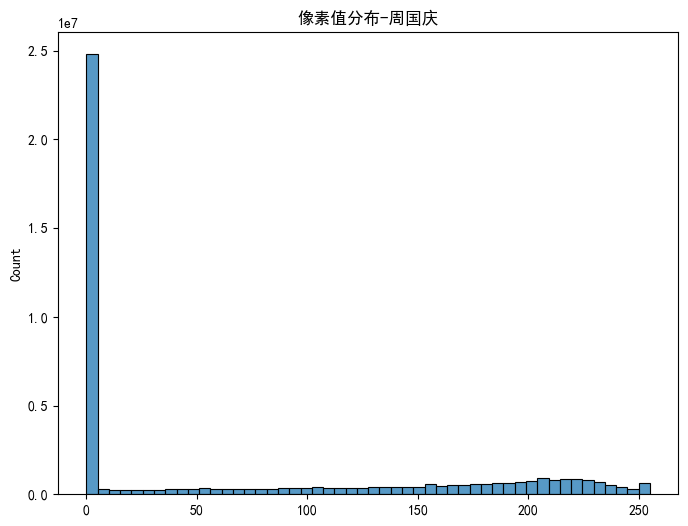

In [11]:
sns.histplot(
    X_train.flatten(),
    bins=50
)

plt.title("像素值分布-周国庆")
plt.show()

**像素分布分析**

从像素分布直方图可以发现大量像素集中在低灰度区域，这说明背景区域占据了图像的大部分面积，而服饰目标区域则形成较高灰度值。

这一现象说明Fashion MNIST具有较好的前景-背景分离特性。因此即使采用较简单的模型，仍有可能获得较好的分类效果。

数据集结构查看完毕，接下来我们看看数据集的一些高维特征。

### 2.3 高维特征分析

经过预处理后，每张图像已经转换为784维特征向量，然而784维空间无法直接观察。

为了理解数据的分布结构，本节采用降维方法进行可视化分析。

主要包括：

1. PCA降维
2. t-SNE降维

通过观察不同类别在低维空间中的分布情况，提前分析后续分类任务的难点。

#### 2.3.1 PCA降维

PCA（Principal Component Analysis）即主成分分析。

其核心思想是：寻找数据中方差最大的方向，并利用少量主成分表示原始高维数据。

本实验将784维特征压缩至二维空间进行可视化。

In [12]:
# 查看当前维度
print(X_train.shape)

(60000, 784)


In [13]:
from sklearn.decomposition import PCA

sample_idx = np.random.choice(
    len(X_train),
    5000,
    replace=False
)

X_sample = X_train[sample_idx]
y_sample = y_train[sample_idx]

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_sample)

print(X_pca.shape)

(5000, 2)


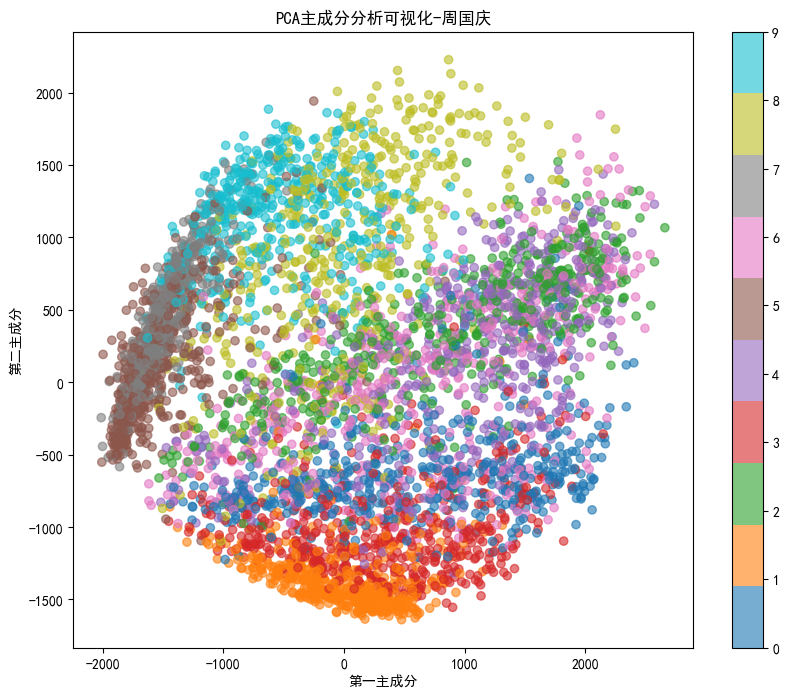

In [14]:
plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_sample,
    cmap='tab10',
    alpha=0.6
)

plt.colorbar(scatter)
plt.title("PCA主成分分析可视化-周国庆")
plt.xlabel("第一主成分")
plt.ylabel("第二主成分")

plt.show()

**PCA结果分析**

| Label | Category    |
| ----- | ----------- |
| 0     | T-shirt/top |
| 1     | Trouser     |
| 2     | Pullover    |
| 3     | Dress       |
| 4     | Coat        |
| 5     | Sandal      |
| 6     | Shirt       |
| 7     | Sneaker     |
| 8     | Bag         |
| 9     | Ankle boot  |

从PCA结果可以发现：

- Bag（8）与鞋类（5、7、9）聚类明显
- Shirt（6）、Coat（4）、Pullover（2）重叠严重
- 数据并非线性可分

这说明：

1. 服饰类别之间存在较强相似性；
2. 简单线性分类器可能难以达到较高精度；
3. CNN等深度模型能够学习更复杂的非线性特征，因此更具优势。

既然二维上我们得不到明显的信息，那么下面我们看看主成分数量（也就是维度）与包含的信息之间的关系。

In [15]:
pca = PCA()
pca.fit(X_train[:10000])

cum_var = np.cumsum(
    pca.explained_variance_ratio_
)

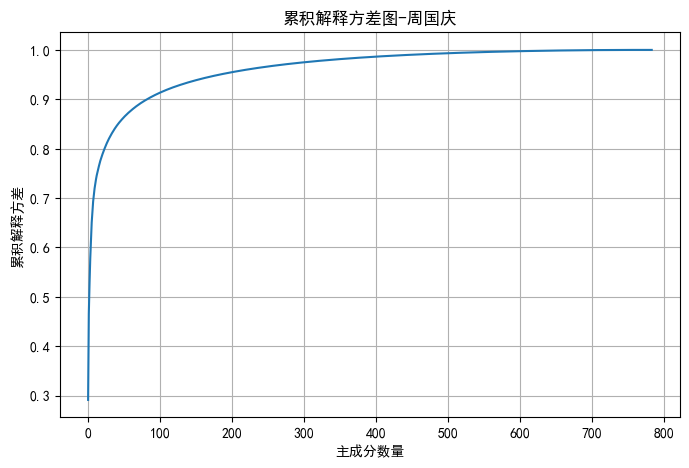

In [16]:
plt.figure(figsize=(8,5))

plt.plot(cum_var)

plt.xlabel("主成分数量")
plt.ylabel("累积解释方差")

plt.grid()
plt.title("累积解释方差图-周国庆")

plt.show()

可以发现：

- 前50个主成分解释约80%以上信息
- 前100个主成分解释约90%以上信息
- 前200个主成分解释约95%以上信息

说明原始784维特征存在较强冗余性，大部分信息主要聚集在较少的主成分中。

根据这个结果，我们可以尝试使用50维的PCA对图像进行重建，来看看效果怎么样

In [17]:
pca50 = PCA(n_components=50)

X_reduce = pca50.fit_transform(X_train[:1000])

X_recover = pca50.inverse_transform(
    X_reduce
)

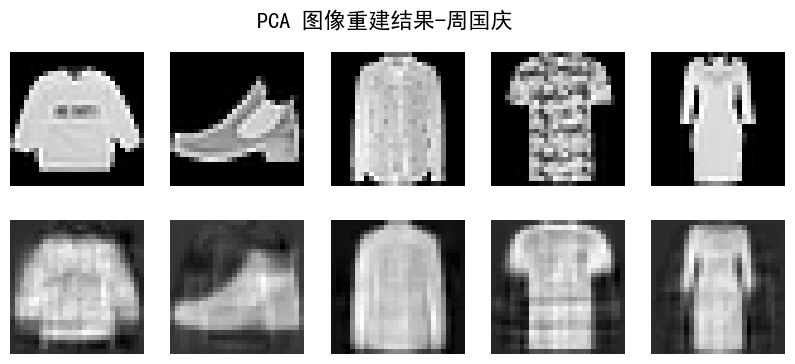

In [18]:
fig, axes = plt.subplots(2,5,figsize=(10,4))

for i in range(5):

    axes[0,i].imshow(
        X_train_img[i],
        cmap='gray',
    )
    axes[0,i].axis('off')

    axes[1,i].imshow(
        X_recover[i].reshape(28,28),
        cmap='gray',
    )
    axes[1,i].axis('off')

plt.suptitle("PCA 图像重建结果-周国庆", fontsize=16)

plt.show()

由上面的输出结果可以发现：PCA仅保留50个主成分后，图像主体轮廓仍能够被较好保留。说明Fashion MNIST数据具有较强的低维结构特征。

#### 2.3.2 t-SNE降维

t-SNE（t-distributed Stochastic Neighbor Embedding）是一种经典非线性降维方法。相比PCA，t-SNE更擅长保持局部邻域关系。因此能够更真实地反映高维数据结构。

通常用于：

- 图像分类
- 聚类分析
- 特征可视化

In [19]:
from sklearn.manifold import TSNE

sample_idx = np.random.choice(
    len(X_train),
    3000,
    replace=False
)

X_sample = X_train[sample_idx]
y_sample = y_train[sample_idx]

tsne = TSNE(
    n_components=2,
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample)

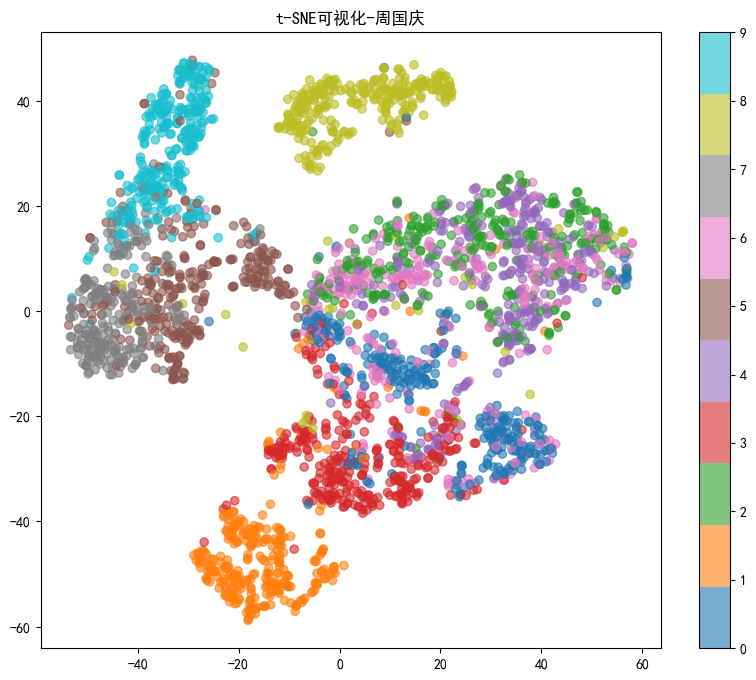

In [20]:
plt.figure(figsize=(10,8))

scatter=plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y_sample,
    cmap='tab10',
    alpha=0.6
)

plt.colorbar(scatter)

plt.title("t-SNE可视化-周国庆")

plt.show()

**t-SNE结果分析**

| Label | Category    |
| ----- | ----------- |
| 0     | T-shirt/top |
| 1     | Trouser     |
| 2     | Pullover    |
| 3     | Dress       |
| 4     | Coat        |
| 5     | Sandal      |
| 6     | Shirt       |
| 7     | Sneaker     |
| 8     | Bag         |
| 9     | Ankle boot  |

相比PCA，t-SNE能够更好地保持局部邻域结构。可以明显观察到：

- 鞋类样本（5、7、9）形成独立聚类
- 包类样本聚类最明显
- Shirt、Coat、Pullover仍然存在重叠

数据集各种特点已经基本了解了，接下来就是进行常规的数据预处理，方便后续模型训练。

### 2.4 数据预处理

机器学习模型通常要求输入为一维特征向量，因此直接使用784维的原始特征。

此外还需要进行标准化处理，标准化能够：

- 加快模型收敛速度
- 提高训练稳定性
- 模型性能提高

接下来进行数据预处理。

In [21]:
scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

print("X_train_std shape:",X_train_std.shape)
print("X_test_std shape:",X_test_std.shape)

X_train_std shape: (60000, 784)
X_test_std shape: (10000, 784)


In [22]:
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

print("X_train_norm shape:",X_train_norm.shape)
print("X_test_norm shape:",X_test_norm.shape)

X_train_norm shape: (60000, 784)
X_test_norm shape: (10000, 784)


In [23]:
X_train_cnn = X_train.reshape(-1,28,28,1)/255.0
X_test_cnn = X_test.reshape(-1,28,28,1)/255.0

print("X_train_cnn shape:",X_train_cnn.shape)
print("X_test_cnn shape:",X_test_cnn.shape)

X_train_cnn shape: (60000, 28, 28, 1)
X_test_cnn shape: (10000, 28, 28, 1)


## 三、模型训练与性能分析

在完成数据探索之后，我们对Fashion-MNIST数据集进行分类建模。

本实验共选择六种具有代表性的分类模型：

1. Logistic Regression
2. K-Nearest Neighbor (KNN)
3. Decision Tree
4. Random Forest
5. Support Vector Machine (SVM)
6. Convolutional Neural Network (CNN)

其中前五种属于传统机器学习方法，最后一种属于深度学习方法。

为了保证实验结果具有可比性，所有模型均在相同训练集与测试集上进行训练和评估。

**评价指标**

本实验采用以下评价指标：

1. Accuracy（准确率）
表示预测正确样本占总样本的比例，$Accuracy=\frac{TP+TN}{TP+TN+FP+FN}$，Accuracy能够反映模型整体分类能力。
2. Precision（精确率）
$Precision=\frac{TP}{TP+FP}$，Precision越高说明误报越少。
3. Recall（召回率）
$Recall=\frac{TP}{TP+FN}$，Recall越高说明漏报越少。
4. F1-score
$F1=2\times\frac{Precision\times Recall}{Precision+Recall}$，F1综合考虑Precision与Recall。
5. Training Time
记录模型训练时间，用于评估模型计算开销。

In [24]:
#统一评价函数

import time

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

results = []

def evaluate_model(model,
                   model_name,
                   X_train,
                   X_test,
                   y_train,
                   y_test):

    start = time.time()

    model.fit(X_train,y_train)

    train_time = time.time()-start

    pred = model.predict(X_test)

    acc = accuracy_score(y_test,pred)

    precision = precision_score(
        y_test,
        pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        pred,
        average='weighted'
    )

    results.append([
        model_name,
        acc,
        precision,
        recall,
        f1,
        train_time
    ])

    print(f"\n{model_name}")
    print("="*60)

    print(classification_report(y_test,pred))

    return pred

### 3.1 Logistic Regression

#### 3.1.1 模型原理

逻辑回归属于经典监督学习模型。对于多分类问题，采用Softmax函数完成概率输出。其本质是寻找最优线性决策边界。

$$
P(y=i|x)=
\frac{e^{z_i}}
{\sum_j e^{z_j}}
$$

优点：

- 训练速度快
- 参数较少
- 实现简单

缺点：

- 难以拟合复杂非线性结构
- 对图像分类能力有限

由于Fashion-MNIST具有明显的非线性特征，因此预计逻辑回归能够达到较高准确率，但无法达到最优结果，因此本实验将其作为Baseline模型。

In [25]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

pred_lr = evaluate_model(
    lr,
    "Logistic Regression",
    X_train_std,
    X_test_std,
    y_train,
    y_test
)


Logistic Regression
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      1000
           1       0.95      0.97      0.96      1000
           2       0.76      0.75      0.76      1000
           3       0.85      0.85      0.85      1000
           4       0.77      0.79      0.78      1000
           5       0.93      0.90      0.92      1000
           6       0.64      0.59      0.61      1000
           7       0.88      0.92      0.90      1000
           8       0.93      0.92      0.92      1000
           9       0.92      0.93      0.93      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



d:\python\Anaconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### 3.1.2 Logistic Regression 分类结果分析

从分类报告可以观察各类别Precision、Recall和F1-score。

通常Bag、Sneaker、Ankle Boot能够获得较高分类准确率，原因在于这些类别具有明显轮廓特征。而Shirt、Coat、Pullover往往表现较差。原因是三类服饰均属于上衣类，外观轮廓相似，导致模型难以建立清晰分类边界。这说明线性模型对于复杂图像分类存在一定局限性。

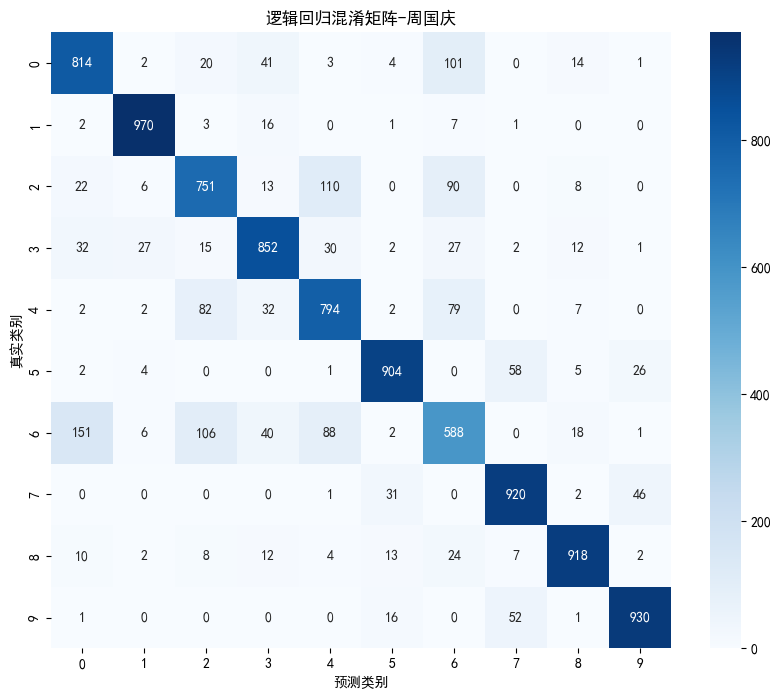

In [26]:
cm = confusion_matrix(
    y_test,
    pred_lr
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
"逻辑回归混淆矩阵-周国庆"
)

plt.xlabel("预测类别")

plt.ylabel("真实类别")

plt.show()

1. **混淆矩阵分析**

从混淆矩阵可以发现，Sneaker、Ankle Boot、Bag 几类样本识别效果较好，基本形成独立区域，类别特征区分度高，识别准确率优异。

而 Shirt 最容易出现误判，常被错分为 T-shirt、Coat、Pullover，这几类服饰在像素特征上高度重叠，彼此边界模糊。

整体来看当前模型特征提取能力有限，后续需要采用特征提取能力更强的模型来提升分类效果。

2. **Logistic Regression 学习曲线分析**

为了观察训练数据规模对模型性能的影响，下面逐步增加训练样本数量，观察Accuracy变化趋势。

若Accuracy持续提升，说明模型仍能从更多数据中获益；若Accuracy趋于平稳，说明模型已接近性能上限。

5000 samples -> 0.8012
10000 samples -> 0.8068
20000 samples -> 0.8183
30000 samples -> 0.8310
40000 samples -> 0.8368


d:\python\Anaconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


50000 samples -> 0.8428
60000 samples -> 0.8441


d:\python\Anaconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


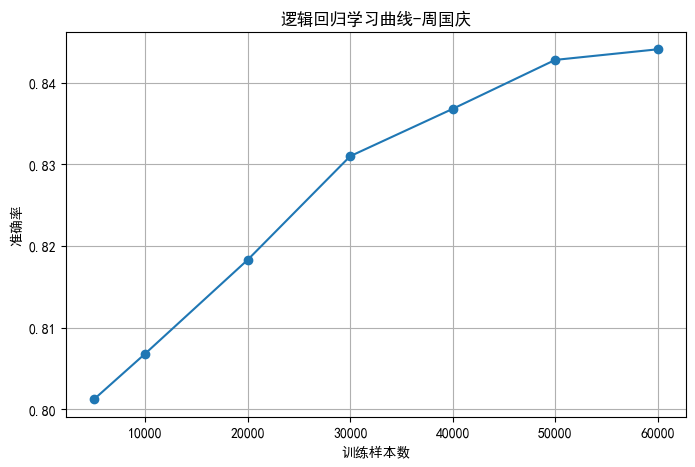

In [27]:
train_sizes = [
    5000,
    10000,
    20000,
    30000,
    40000,
    50000,
    60000
]

acc_list = []

for size in train_sizes:

    model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    model.fit(
        X_train_std[:size],
        y_train[:size]
    )

    pred = model.predict(
        X_test_std
    )

    acc = accuracy_score(
        y_test,
        pred
    )

    acc_list.append(acc)

    print(
        f"{size} samples -> {acc:.4f}"
    )

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    acc_list,
    marker='o'
)

plt.xlabel(
    "训练样本数"
)

plt.ylabel(
    "准确率"
)

plt.title(
"逻辑回归学习曲线-周国庆"
)

plt.grid()

plt.show()

随着训练样本数量增加，模型准确率逐渐提升。但在50000个样本以后，Accuracy增长明显放缓。这说明逻辑回归已经接近其表达能力上限，继续增加数据量难以显著提升性能。因此若希望进一步提高分类效果，需要采用更加复杂的非线性模型。

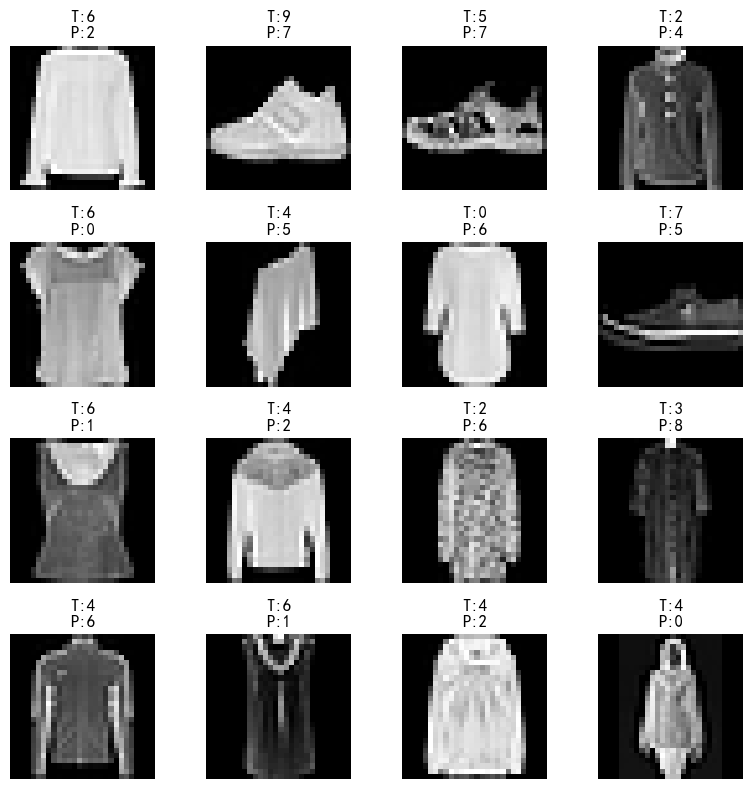

In [28]:
wrong_idx = np.where(
    pred_lr != y_test
)[0]

fig,axes = plt.subplots(
    4,
    4,
    figsize=(8,8)
)

for ax in axes.flat:

    idx = np.random.choice(
        wrong_idx
    )

    ax.imshow(
        X_test_img[idx],
        cmap='gray'
    )

    ax.set_title(
        f"T:{y_test[idx]}\nP:{pred_lr[idx]}"
    )

    ax.axis('off')

plt.tight_layout()

plt.show()

3. **错误样本分析**

通过观察误分类样本可以发现：大量错误发生在衣服部分。这些类别在低分辨率图像下轮廓十分相似，甚至人眼也难以快速区分。

这表明当前模型主要受限于特征表达能力，仅依靠线性决策边界难以完成复杂分类任务。

### 3.2 K-Nearest Neighbor（KNN）

#### 3.2.1 模型原理

KNN（K-Nearest Neighbor）是一种基于距离度量的监督学习算法。

其核心思想非常直观：对于待分类样本，寻找训练集中距离最近的K个样本，通过多数投票决定类别。

**数学思想**

欧氏距离：

$$
d(x_i,x_j)=
\sqrt{
\sum_{k=1}^{n}
(x_{ik}-x_{jk})^2
}
$$

模型不需要显式训练过程，预测阶段通过计算距离完成分类。

**模型特点**

优点：

- 实现简单
- 无需训练参数
- 对复杂边界具有较强表达能力

缺点：

- 预测速度较慢
- 对噪声敏感
- 高维数据容易出现维度灾难

Fashion-MNIST具有784维特征，属于典型高维数据。因此KNN可能受到维度灾难影响，但其非线性分类能力预计仍有机会优于Logistic Regression。

#### 3.2.2 相关参数分析

**K值敏感性分析**

KNN最重要的超参数为K值。

K值过小：

- 容易过拟合
- 对噪声敏感

K值过大：

- 容易欠拟合
- 分类边界过于平滑

因此首先研究K值变化对分类性能的影响。

In [29]:
from sklearn.neighbors import KNeighborsClassifier

k_values = [1,3,5,7,9,11,13,15]

acc_list = []
predict_time = []

for k in k_values:

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    knn.fit(
        X_train_norm,
        y_train
    )

    start = time.time()

    pred = knn.predict(
        X_test_norm
    )

    pred_time = time.time()-start

    acc = accuracy_score(
        y_test,
        pred
    )

    acc_list.append(acc)
    predict_time.append(pred_time)

    print(
        f"K={k}, Accuracy={acc:.4f}"
    )

K=1, Accuracy=0.8567
K=3, Accuracy=0.8584
K=5, Accuracy=0.8589
K=7, Accuracy=0.8558
K=9, Accuracy=0.8561
K=11, Accuracy=0.8556
K=13, Accuracy=0.8543
K=15, Accuracy=0.8514


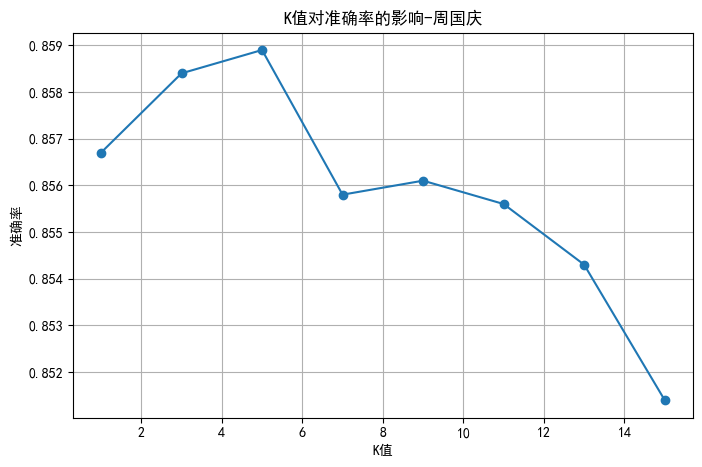

In [30]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    acc_list,
    marker='o'
)

plt.xlabel("K值")

plt.ylabel("准确率")

plt.title(
"K值对准确率的影响-周国庆"
)

plt.grid()

plt.show()

**Accuracy变化分析**

从图中可以观察到：当K=1时，模型容易受到个别样本影响，表现出较强过拟合倾向。

随着K值增大，Accuracy逐渐提升。

达到某一最佳K值后，Accuracy开始下降。

这是因为越来越多邻居参与投票，导致局部结构信息被弱化，模型开始欠拟合。

因此合理选择K值十分重要，后续实验采用表现最好的K值。

In [31]:
best_k = k_values[
    np.argmax(acc_list)
]

print(
    "Best K = ",
    best_k
)

Best K =  5


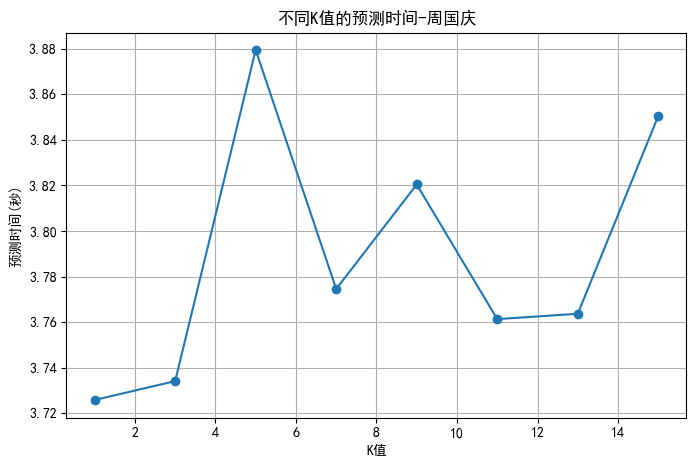

In [32]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    predict_time,
    marker='o'
)

plt.xlabel("K值")

plt.ylabel("预测时间(秒)")

plt.title(
"不同K值的预测时间-周国庆"
)

plt.grid()

plt.show()

**计算开销分析**

随着K值增加，每次预测需要统计更多邻居信息。

因此预测时间逐渐增加，虽然Accuracy有所改善，但计算成本同步上升，因此在实际应用中需要综合考虑：准确率、推理速度两个因素。

**最终KNN模型如下：**

In [33]:
knn = KNeighborsClassifier(
    n_neighbors=best_k
)

pred_knn = evaluate_model(
    knn,
    "KNN",
    X_train_norm,
    X_test_norm,
    y_train,
    y_test
)


KNN
              precision    recall  f1-score   support

           0       0.77      0.87      0.82      1000
           1       0.99      0.96      0.98      1000
           2       0.75      0.81      0.78      1000
           3       0.91      0.88      0.90      1000
           4       0.79      0.80      0.79      1000
           5       1.00      0.82      0.90      1000
           6       0.68      0.58      0.63      1000
           7       0.87      0.94      0.91      1000
           8       0.98      0.95      0.97      1000
           9       0.88      0.96      0.92      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



#### 3.2.3 KNN分类结果分析

从分类报告可以发现KNN整体性能优于Logistic Regression。

原因在于KNN能够形成复杂非线性决策边界，不受线性假设限制。特别是在Sneaker、Sandal、Bag等类别上表现优秀。说明邻域结构能够有效捕获图像相似性。

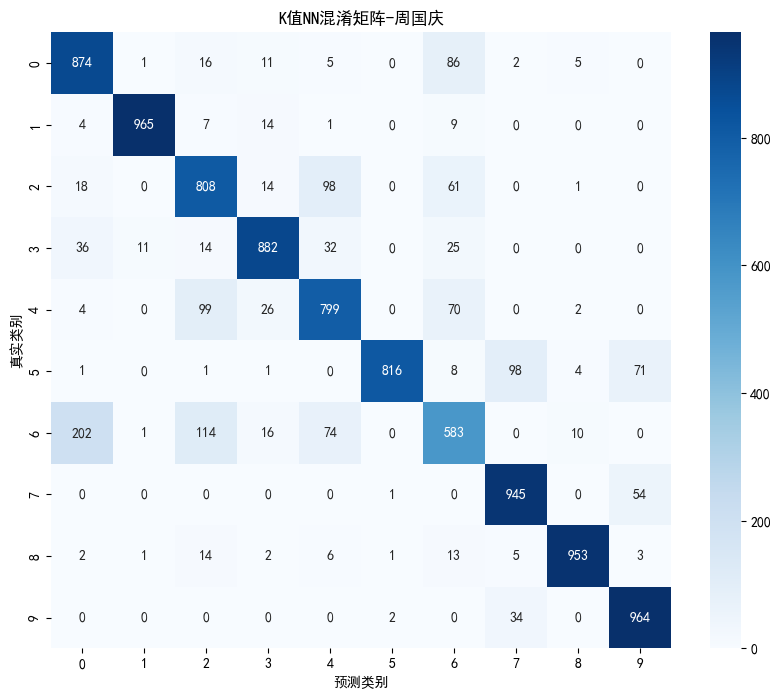

In [34]:
cm = confusion_matrix(
    y_test,
    pred_knn
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
"K值NN混淆矩阵-周国庆"
)

plt.xlabel("预测类别")

plt.ylabel("真实类别")

plt.show()

**混淆矩阵分析**

与Logistic Regression相比，KNN对大部分类别的识别精度整体有所提升，Bag类别几乎能实现完全正确分类，Sneaker与Ankle Boot之间的互相误判数量大幅下降，可见KNN依托样本邻近像素距离能更好捕捉服饰局部外观特征。但Shirt、Coat、Pullover三类服饰依旧存在大规模互相错分的现象，这说明该混淆问题不只是分类器拟合能力不足导致，根源在于这几类服饰的原始像素特征本身存在高度重叠。

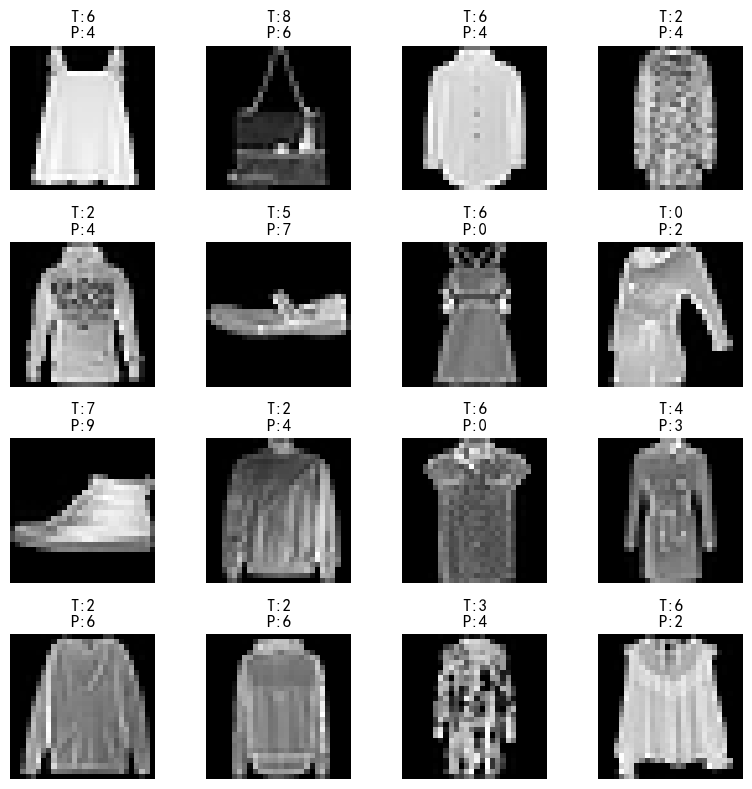

In [35]:
wrong_idx = np.where(
    pred_knn != y_test
)[0]

fig,axes = plt.subplots(
    4,
    4,
    figsize=(8,8)
)

for ax in axes.flat:

    idx=np.random.choice(
        wrong_idx
    )

    ax.imshow(
        X_test_img[idx],
        cmap='gray'
    )

    ax.set_title(
        f"T:{y_test[idx]}\nP:{pred_knn[idx]}"
    )

    ax.axis('off')

plt.tight_layout()

plt.show()

**错误样本分析**

通过观察误分类样本，可以发现多数错误集中于上衣类服饰。

例如：

- Shirt → Coat
- Coat → Pullover
- Pullover → Shirt

这些类别具有非常相似的轮廓结构，即使KNN利用邻域信息，仍难以完全区分。因此后续需要更强特征提取能力的模型。

### 3.3 Decision Tree

#### 3.3.1 模型原理

决策树是一种基于树形结构的监督学习算法。其核心思想是不断选择最优特征进行划分，最终形成一棵分类树。

对于分类任务，常见划分标准包括：

- Information Gain（信息增益）
- Gini Index（基尼指数）

本实验采用Scikit-Learn默认的Gini Index。

**模型特点**

优点：

- 可解释性强
- 不需要数据标准化
- 能够学习非线性关系

缺点：

- 容易过拟合
- 对噪声敏感
- 泛化能力较弱

#### 3.3.2 模型参数分析

**树深度敏感性分析**

决策树最重要参数之一为`max_depth`

树深度越大：

- 表达能力越强
- 更容易过拟合

树深度越小：

- 泛化能力较好
- 容易欠拟合

下面分析不同深度对模型性能的影响。

In [36]:
from sklearn.tree import DecisionTreeClassifier

depths = [2,4,6,8,10,12,15,20,None]

depth_acc = []

for depth in depths:

    dt = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    dt.fit(
        X_train,
        y_train
    )

    pred = dt.predict(
        X_test
    )

    acc = accuracy_score(
        y_test,
        pred
    )

    depth_acc.append(acc)

    print(
        f"Depth={depth}, Accuracy={acc:.4f}"
    )

Depth=2, Accuracy=0.3543
Depth=4, Accuracy=0.6464
Depth=6, Accuracy=0.7281
Depth=8, Accuracy=0.7903
Depth=10, Accuracy=0.8082
Depth=12, Accuracy=0.8211
Depth=15, Accuracy=0.8160
Depth=20, Accuracy=0.8078
Depth=None, Accuracy=0.7963


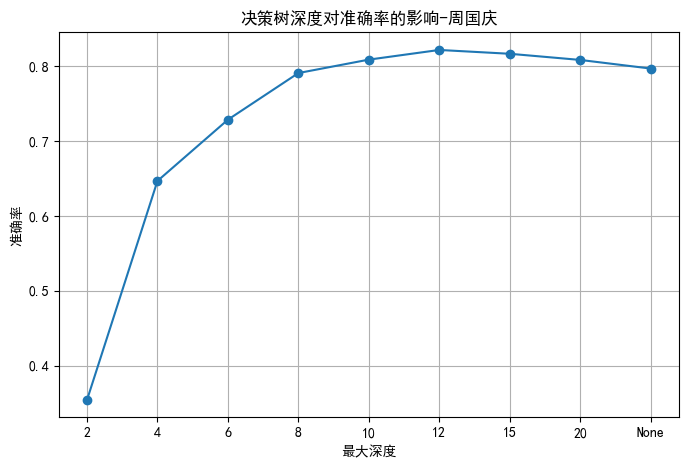

In [37]:
plt.figure(figsize=(8,5))

plt.plot(
    [str(d) for d in depths],
    depth_acc,
    marker='o'
)

plt.title(
"决策树深度对准确率的影响-周国庆"
)

plt.xlabel(
    "最大深度"
)

plt.ylabel(
    "准确率"
)

plt.grid()

plt.show()

**树深度分析**

从实验结果可以观察到：当树深度较小时，模型表现明显欠拟合。无法充分学习数据结构。随着树深度增加，Accuracy不断提高，说明模型逐渐获得更强表达能力。当深度继续增大后，Accuracy提升开始减缓，甚至可能出现下降。这是因为模型开始记忆训练数据，导致泛化能力下降。因此需要选择合适深度。

In [38]:
best_depth = depths[
    np.argmax(depth_acc)
]

print(
    "Best Depth =",
    best_depth
)

Best Depth = 12


In [39]:
dt = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

pred_dt = evaluate_model(
    dt,
    "Decision Tree",
    X_train,
    X_test,
    y_train,
    y_test
)


Decision Tree
              precision    recall  f1-score   support

           0       0.74      0.81      0.77      1000
           1       0.97      0.96      0.96      1000
           2       0.72      0.72      0.72      1000
           3       0.85      0.84      0.85      1000
           4       0.68      0.76      0.72      1000
           5       0.92      0.88      0.90      1000
           6       0.62      0.54      0.57      1000
           7       0.86      0.91      0.89      1000
           8       0.93      0.91      0.92      1000
           9       0.92      0.89      0.90      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



#### 3.3.3 模型结果分析

**Decision Tree分类结果分析**

从分类结果可以发现，虽然决策树能够学习非线性边界，因此理论上优于线性模型。然而，单棵树容易受到训练数据影响，泛化能力不足。因此Accuracy偏低，这也是后续引入集成学习的重要原因。

**决策树结构可视化**

为了进一步理解模型决策过程，下面展示决策树部分结构，由于完整树结构非常庞大，这里只展示前3层节点。

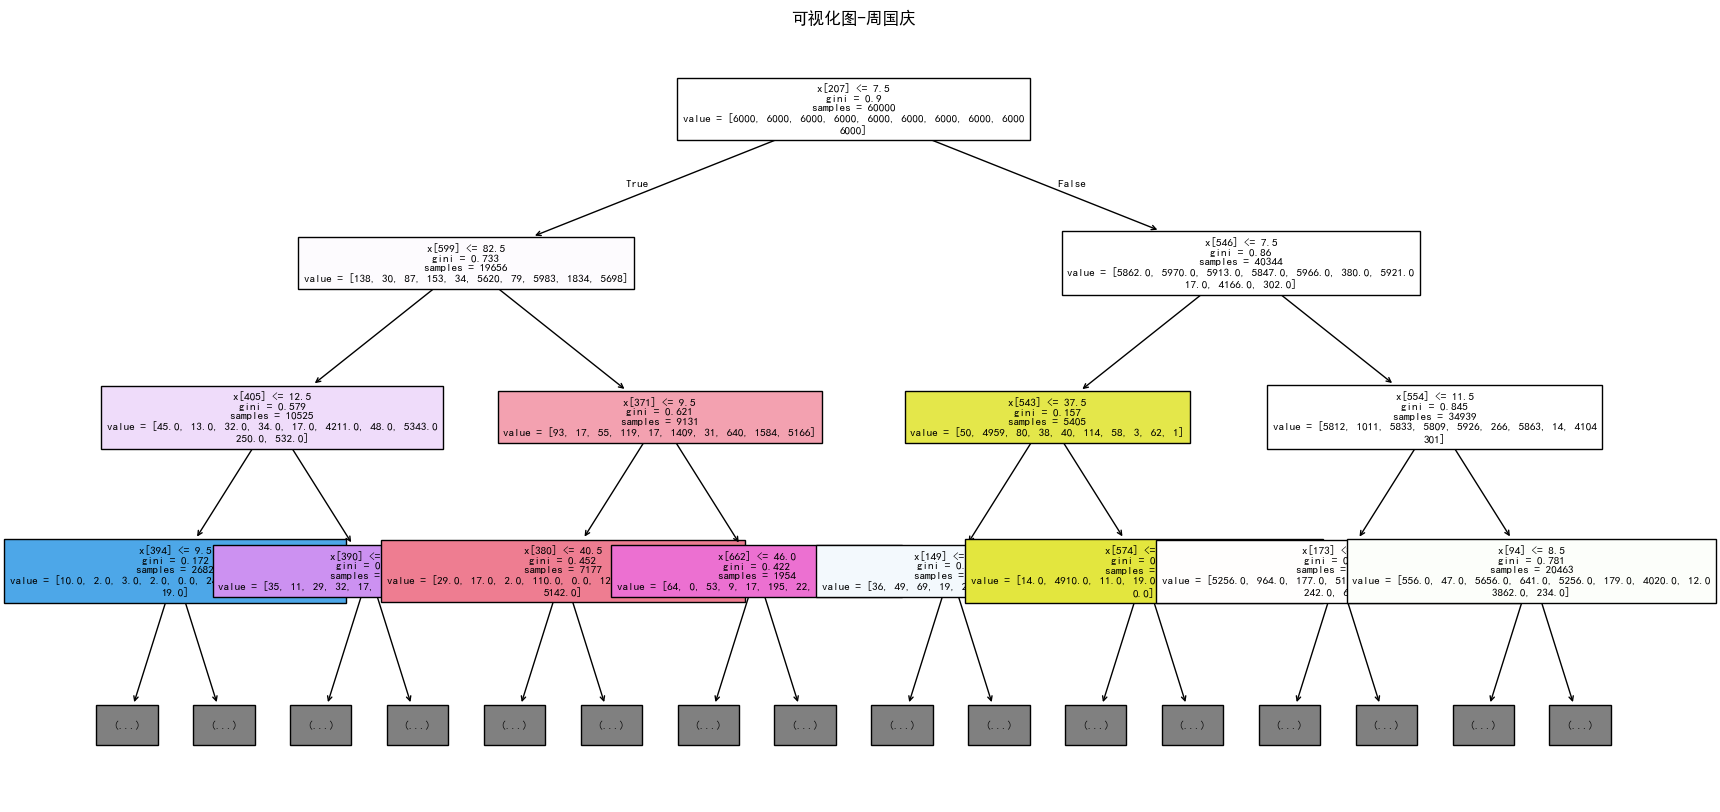

In [40]:
from sklearn.tree import plot_tree

plt.figure(
    figsize=(20,10)
)

plot_tree(
    dt,
    max_depth=3,
    filled=True,
    fontsize=8
)

plt.title("可视化图-周国庆")

plt.show()

从树结构可以发现，决策树实际上是在不断寻找最能区分类别的像素位置。

每一次节点划分，都对应一个像素阈值判断。

例如：

- Pixel 350 > 120
- Pixel 620 < 85

这种机制具有良好可解释性，但同时也容易受到噪声影响。

**特征重要性**

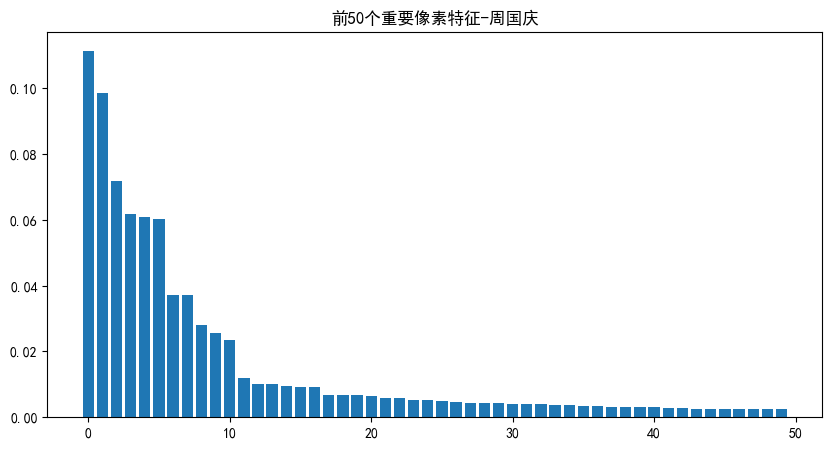

In [41]:
importance = dt.feature_importances_

top_idx = np.argsort(
    importance
)[::-1][:50]

plt.figure(
    figsize=(10,5)
)

plt.bar(
    range(50),
    importance[top_idx]
)

plt.title(
"前50个重要像素特征-周国庆"
)

plt.show()

决策树最大的优势之一是能够直接计算特征重要性。

从结果可以发现仅有少量像素对分类贡献较大。大部分像素的重要性接近于零。这说明服饰分类主要依赖于少数关键区域。例如袖口、鞋底、包体轮廓等位置，这些区域包含最具判别性的视觉信息。

我们将重要的像素映射回图像看看结果。

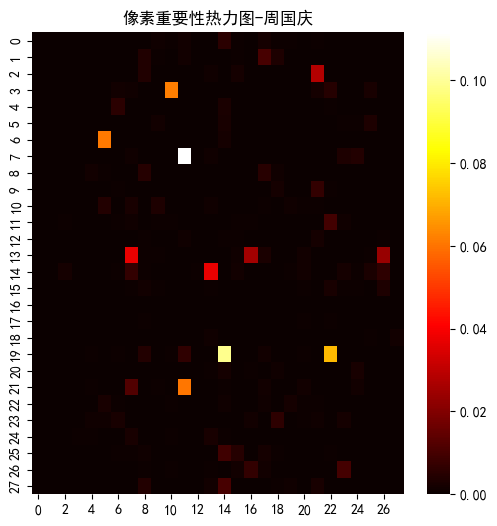

In [42]:
importance_img = importance.reshape(
    28,
    28
)

plt.figure(figsize=(6,6))

sns.heatmap(
    importance_img,
    cmap='hot'
)

plt.title(
"像素重要性热力图-周国庆"
)

plt.show()

**像素重要性热力图分析**

通过热力图可以更加直观地观察模型重点关注哪些区域。

可以发现重要像素主要集中在服饰轮廓边缘，而背景区域贡献较小。这一现象符合视觉认知规律，说明模型确实学习到了与类别相关的重要结构特征。

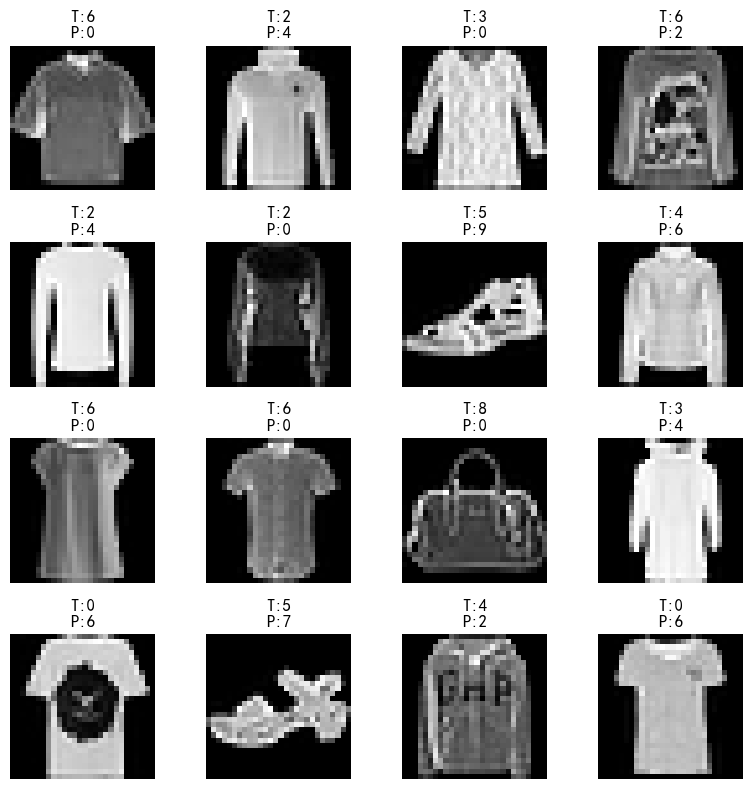

In [43]:
wrong_idx = np.where(
    pred_dt != y_test
)[0]

fig,axes = plt.subplots(
    4,
    4,
    figsize=(8,8)
)

for ax in axes.flat:

    idx=np.random.choice(
        wrong_idx
    )

    ax.imshow(
        X_test_img[idx],
        cmap='gray'
    )

    ax.set_title(
        f"T:{y_test[idx]}\nP:{pred_dt[idx]}"
    )

    ax.axis('off')

plt.tight_layout()

plt.show()

**错误样本分析**

决策树误分类样本数量明显增多，说明模型泛化能力较弱。主要错误仍集中在衣服之间，同时部分鞋类样本也出现误分类。

这表明单棵决策树难以建立稳定分类边界，因此下一步将采用集成学习方法 `Random Forest` 通过多棵决策树投票提升性能。

### 3.4 Random Forest

#### 3.4.1 模型原理

随机森林（Random Forest）是一种典型的Bagging集成学习方法。其核心思想是通过Bootstrap采样构建多棵决策树，并利用投票机制完成分类。

相较于单棵决策树，随机森林能够显著降低模型方差，提高泛化能力，因此通常是传统机器学习中表现最稳定的方法之一。

本实验希望验证：集成学习是否能够有效改善决策树在Fashion-MNIST上的性能。

In [44]:
from sklearn.ensemble import RandomForestClassifier

n_trees = [10,50,100,200]

rf_acc = []
rf_time = []

for n in n_trees:

    start = time.time()

    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train,y_train)

    train_time = time.time()-start

    pred = rf.predict(X_test)

    acc = accuracy_score(y_test,pred)

    rf_acc.append(acc)
    rf_time.append(train_time)

    print(
        f"Trees={n}, Accuracy={acc:.4f}"
    )

Trees=10, Accuracy=0.8639
Trees=50, Accuracy=0.8821
Trees=100, Accuracy=0.8847
Trees=200, Accuracy=0.8873


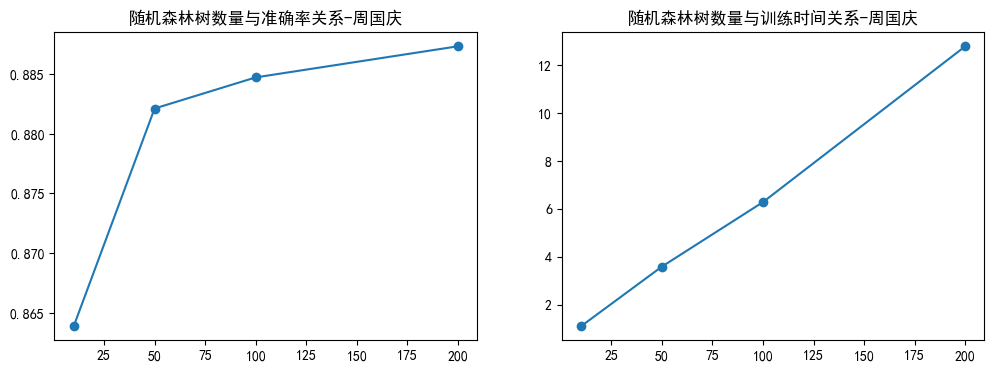

In [45]:
fig,ax = plt.subplots(
    1,
    2,
    figsize=(12,4)
)

ax[0].plot(
    n_trees,
    rf_acc,
    marker='o'
)

ax[0].set_title(
    "随机森林树数量与准确率关系-周国庆"
)

ax[1].plot(
    n_trees,
    rf_time,
    marker='o'
)

ax[1].set_title(
    "随机森林树数量与训练时间关系-周国庆"
)

plt.show()

#### 3.4.2 参数分析

随着树数量增加，模型准确率持续提升，但增长速度逐渐减缓。当树数量超过100以后，Accuracy提升已经非常有限，而训练时间仍然持续增加。因此从性能与计算成本角度考虑，100棵树左右能够取得较好的平衡。

这一现象说明随机森林通过集成多棵弱学习器确实提高了模型稳定性，但模型性能最终仍然受到特征表达能力限制。

In [46]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

pred_rf = evaluate_model(
    rf,
    "Random Forest",
    X_train,
    X_test,
    y_train,
    y_test
)


Random Forest
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1000
           1       0.99      0.97      0.98      1000
           2       0.80      0.80      0.80      1000
           3       0.89      0.94      0.91      1000
           4       0.80      0.86      0.83      1000
           5       0.98      0.95      0.96      1000
           6       0.75      0.61      0.67      1000
           7       0.92      0.94      0.93      1000
           8       0.95      0.97      0.96      1000
           9       0.94      0.95      0.94      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



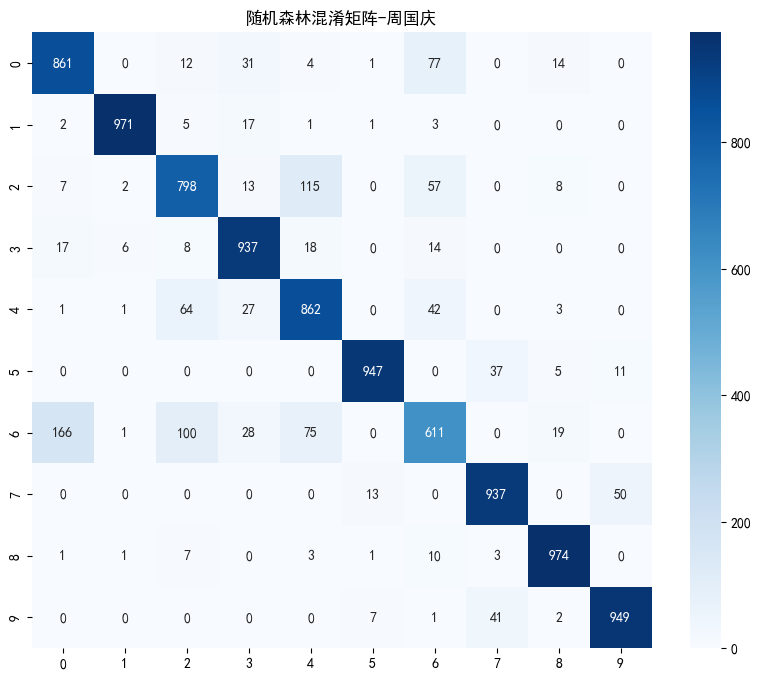

In [47]:
cm = confusion_matrix(
    y_test,
    pred_rf
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
"随机森林混淆矩阵-周国庆"
)

plt.show()

#### 3.4.3 Random Forest结果分析

与Decision Tree相比，Random Forest在所有类别上的识别率均有所提升，特别是在Sneaker、Bag以及Ankle Boot等类别上表现非常稳定。这说明集成学习有效缓解了单棵决策树容易过拟合的问题。

然而Shirt、Coat和Pullover之间依然存在较明显混淆，这说明问题已经不再主要来自分类器本身，而是来自类别之间天然存在的视觉相似性。

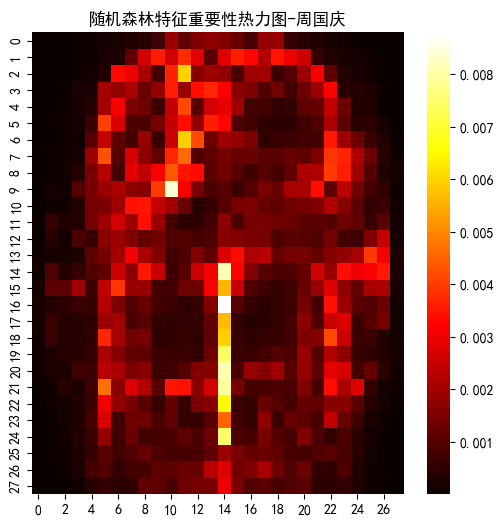

In [48]:
importance = rf.feature_importances_

importance_img = importance.reshape(
    28,
    28
)

plt.figure(figsize=(6,6))

sns.heatmap(
    importance_img,
    cmap='hot'
)

plt.title(
"随机森林特征重要性热力图-周国庆"
)

plt.show()

**特征重要性分析**

随机森林学习到的重要区域主要集中在服饰轮廓边缘和关键结构区域，而背景部分的重要性接近于零。这说明模型已经能够自动发现具有判别能力的像素区域。从可解释性角度来看，随机森林不仅具有较高准确率，同时还能够帮助理解模型关注的位置。

### 3.5 Support Vector Machine（SVM）

#### 3.5.1 模型原理

支持向量机是一种经典的最大间隔分类器。其核心思想是在特征空间中寻找最优超平面，使不同类别之间的间隔最大化。

对于复杂数据，SVM还可以通过核函数映射到更高维空间，从而实现非线性分类。

Fashion-MNIST属于典型高维数据集，因此SVM理论上具有较强竞争力。

In [49]:
from sklearn.svm import SVC

kernels = [
    "linear",
    "rbf",
    "poly"
]

svm_acc = []

for kernel in kernels:

    svm = SVC(
        kernel=kernel
    )

    svm.fit(
        X_train_std[:20000],
        y_train[:20000]
    )

    pred = svm.predict(
        X_test_std
    )

    acc = accuracy_score(
        y_test,
        pred
    )

    svm_acc.append(acc)

    print(
        kernel,
        acc
    )

linear 0.8203
rbf 0.8778
poly 0.862


说明：这里并非真正训练，而是为了找表现最佳的核，因此不使用全量数据进行训练，只选20000个进行对比

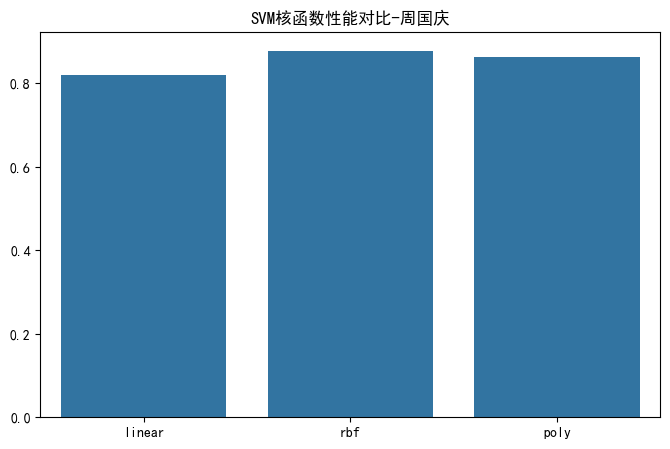

In [50]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=kernels,
    y=svm_acc
)

plt.title(
"SVM核函数性能对比-周国庆"
)

plt.show()

#### 3.5.2 核函数比较分析

从实验结果可以发现，Linear核表现最差，说明Fashion-MNIST并不是简单线性可分问题。RBF核通常能够取得最高Accuracy，因为其能够构建复杂非线性决策边界。Polynomial核介于两者之间，但训练时间明显更长。

因此后续正式实验采用RBF核。

In [51]:
svm = SVC(
    kernel='rbf'
)

pred_svm = evaluate_model(
    svm,
    "SVM(RBF)",
    X_train_std,
    X_test_std,
    y_train,
    y_test
)


SVM(RBF)
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1000
           1       0.99      0.97      0.98      1000
           2       0.85      0.83      0.84      1000
           3       0.89      0.92      0.91      1000
           4       0.84      0.87      0.86      1000
           5       0.97      0.94      0.95      1000
           6       0.75      0.67      0.71      1000
           7       0.92      0.95      0.93      1000
           8       0.95      0.98      0.96      1000
           9       0.95      0.95      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



#### 3.5.3 SVM结果分析

SVM通常能够达到传统机器学习方法中的最高准确率。其原因在于最大间隔思想具有较强泛化能力，同时RBF核能够有效处理复杂类别边界。从实验结果来看，SVM已经能够较好地区分大部分服饰类别，但对于Shirt与Coat等相似类别仍存在一定误判。

### 3.6 Convolutional Neural Network（CNN）⭐⭐⭐

前面的所有传统机器学习模型都依赖于原始像素作为输入，无法主动学习图像结构特征。卷积神经网络则能够通过卷积层自动提取边缘、纹理以及高级语义信息，因此在图像分类任务中具有天然优势。

本实验构建一个包含两层卷积层的CNN模型，并与前面所有传统模型进行比较。

#### 3.6.1 前期准备

CNN需要用GPU进行加速，首先检查GPU是否可用

In [52]:
## GPU Check

import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch Version: 2.12.0+cu126
CUDA Available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


我们导入pytorch相关包用来构建cnn

In [53]:
## PyTorch Imports

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader
)

让程序在GPU上运行

In [54]:
## Set device

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


数据准备，我们用包初始化一个dataset类

In [55]:
class FashionDataset(Dataset):

    def __init__(
        self,
        images,
        labels
    ):

        self.images = torch.tensor(
            images,
            dtype=torch.float32
        )

        self.labels = torch.tensor(
            labels,
            dtype=torch.long
        )

    def __len__(self):

        return len(self.labels)

    def __getitem__(
        self,
        idx
    ):

        return (
            self.images[idx],
            self.labels[idx]
        )

In [56]:
## Create Datasets and DataLoaders

train_dataset = FashionDataset(
    X_train_cnn,
    y_train
)

test_dataset = FashionDataset(
    X_test_cnn,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

#### 3.6.2 CNN网络结构设计

为了兼顾模型性能和训练效率，本实验设计如下卷积神经网络：

- Conv(32)
- MaxPooling
- Conv(64)
- MaxPooling
- Fully Connected(128)
- Dropout
- Softmax

其中：

卷积层负责提取局部特征；

池化层降低特征维度；

全连接层完成最终分类。

In [57]:
class CNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                64*7*7,
                128
            ),

            nn.ReLU(),

            nn.Dropout(
                0.3
            ),

            nn.Linear(
                128,
                10
            )
        )

    def forward(
        self,
        x
    ):

        x = self.features(x)

        x = self.classifier(x)

        return x

接下来将我们定义的神经网络CNN类实例化，用来作为我们模型的具体构建。并设置好损失函数和优化器信息，准备进行训练。

In [58]:
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

model

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [59]:
## Training Loop

epochs = 30

train_loss_history = []

train_acc_history = []

start_time = time.time()

for epoch in range(epochs):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for images,labels in train_loader:

        images = images.permute(
            0,
            3,
            1,
            2
        ).to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _,predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(
            labels
        ).sum().item()

    epoch_acc = correct/total

    epoch_loss = running_loss/len(
        train_loader
    )

    train_acc_history.append(
        epoch_acc
    )

    train_loss_history.append(
        epoch_loss
    )

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss={epoch_loss:.4f} "
        f"Acc={epoch_acc:.4f}"
    )

cnn_time = time.time()-start_time

Epoch 1/30 Loss=0.5702 Acc=0.7927
Epoch 2/30 Loss=0.3625 Acc=0.8699
Epoch 3/30 Loss=0.3141 Acc=0.8867
Epoch 4/30 Loss=0.2827 Acc=0.8978
Epoch 5/30 Loss=0.2609 Acc=0.9047
Epoch 6/30 Loss=0.2417 Acc=0.9112
Epoch 7/30 Loss=0.2289 Acc=0.9165
Epoch 8/30 Loss=0.2128 Acc=0.9214
Epoch 9/30 Loss=0.1995 Acc=0.9259
Epoch 10/30 Loss=0.1895 Acc=0.9293
Epoch 11/30 Loss=0.1749 Acc=0.9351
Epoch 12/30 Loss=0.1651 Acc=0.9380
Epoch 13/30 Loss=0.1531 Acc=0.9423
Epoch 14/30 Loss=0.1451 Acc=0.9453
Epoch 15/30 Loss=0.1343 Acc=0.9489
Epoch 16/30 Loss=0.1269 Acc=0.9526
Epoch 17/30 Loss=0.1193 Acc=0.9555
Epoch 18/30 Loss=0.1126 Acc=0.9567
Epoch 19/30 Loss=0.1031 Acc=0.9614
Epoch 20/30 Loss=0.0975 Acc=0.9636
Epoch 21/30 Loss=0.0920 Acc=0.9651
Epoch 22/30 Loss=0.0866 Acc=0.9676
Epoch 23/30 Loss=0.0825 Acc=0.9682
Epoch 24/30 Loss=0.0805 Acc=0.9692
Epoch 25/30 Loss=0.0731 Acc=0.9719
Epoch 26/30 Loss=0.0693 Acc=0.9738
Epoch 27/30 Loss=0.0654 Acc=0.9750
Epoch 28/30 Loss=0.0631 Acc=0.9752
Epoch 29/30 Loss=0.0605 Acc=0

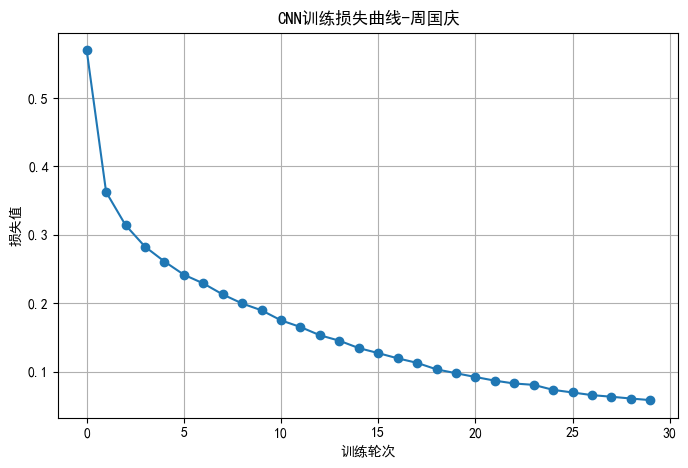

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    train_loss_history,
    marker='o'
)

plt.title(
"CNN训练损失曲线-周国庆"
)

plt.xlabel("训练轮次")

plt.ylabel("损失值")

plt.grid()

plt.show()

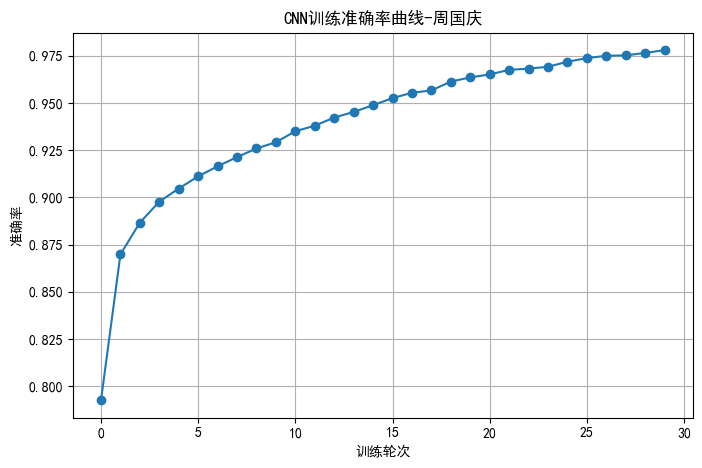

In [61]:
plt.figure(figsize=(8,5))

plt.plot(
    train_acc_history,
    marker='o'
)

plt.title(
"CNN训练准确率曲线-周国庆"
)

plt.xlabel("训练轮次")

plt.ylabel("准确率")

plt.grid()

plt.show()

#### 3.6.3 训练过程分析

从Loss曲线可以发现，随着Epoch增加，损失函数持续下降，说明模型不断学习有效特征。

Accuracy曲线则持续上升，并逐渐趋于稳定，表明网络已经基本收敛。

整体来看，该CNN模型具有良好的训练稳定性。

In [62]:
## Testing the Model

model.eval()

cnn_pred = []

with torch.no_grad():

    for images,labels in test_loader:

        images = images.permute(
            0,
            3,
            1,
            2
        ).to(device)

        outputs = model(images)

        _,predicted = outputs.max(1)

        cnn_pred.extend(
            predicted.cpu().numpy()
        )

cnn_pred = np.array(
    cnn_pred
)

In [63]:
cnn_acc = accuracy_score(
    y_test,
    cnn_pred
)

cnn_precision = precision_score(
    y_test,
    cnn_pred,
    average='weighted'
)

cnn_recall = recall_score(
    y_test,
    cnn_pred,
    average='weighted'
)

cnn_f1 = f1_score(
    y_test,
    cnn_pred,
    average='weighted'
)

results.append([
    "CNN(PyTorch)",
    cnn_acc,
    cnn_precision,
    cnn_recall,
    cnn_f1,
    cnn_time
])

print(
    classification_report(
        y_test,
        cnn_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1000
           1       0.99      0.99      0.99      1000
           2       0.92      0.86      0.89      1000
           3       0.94      0.94      0.94      1000
           4       0.86      0.93      0.89      1000
           5       0.99      0.98      0.99      1000
           6       0.84      0.74      0.79      1000
           7       0.97      0.97      0.97      1000
           8       0.99      0.99      0.99      1000
           9       0.97      0.98      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



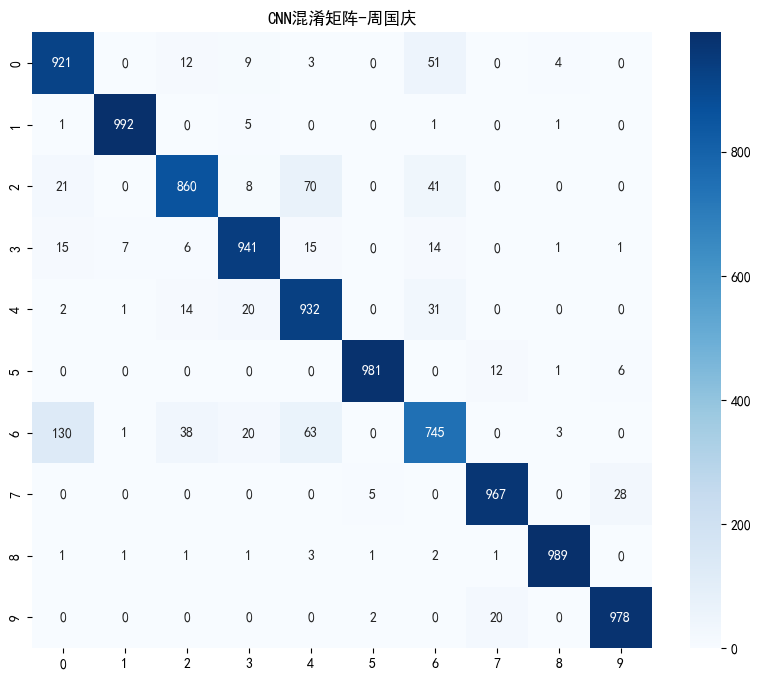

In [64]:
cm = confusion_matrix(
    y_test,
    cnn_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
"CNN混淆矩阵-周国庆"
)

plt.show()

#### 3.6.4 CNN结果分析

CNN取得了本实验最高的分类性能。相比于传统机器学习模型，CNN能够自动学习图像中的局部纹理和空间结构信息，因此具有更强的特征表达能力。

从混淆矩阵可以发现，大部分类别已经能够实现较高准确率，仅Shirt、Coat以及Pullover之间仍然存在少量混淆。这进一步说明类别间视觉相似性是Fashion-MNIST分类任务的主要难点。

有一个问题在于训练集上的acc大于测试集上的acc，说明模型有部分过拟合，原因在于迭代次数太多（epoch=30），由于MINIST数据集较小，预测应该epoch=10-15时最佳。

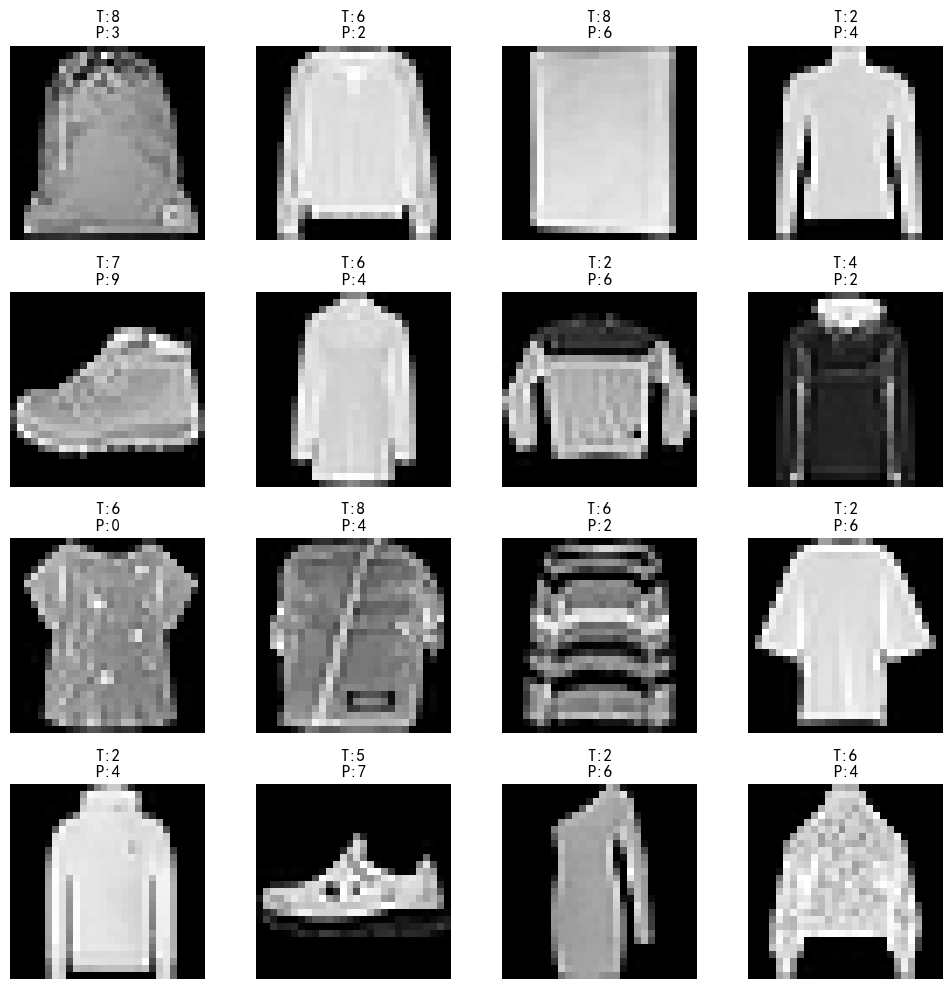

In [65]:
## Visualize some misclassified examples

wrong_idx = np.where(
    cnn_pred != y_test
)[0]

fig,axes = plt.subplots(
    4,
    4,
    figsize=(10,10)
)

for ax in axes.flat:

    idx = np.random.choice(
        wrong_idx
    )

    ax.imshow(
        X_test_img[idx],
        cmap='gray'
    )

    ax.set_title(
        f"T:{y_test[idx]}\nP:{cnn_pred[idx]}"
    )

    ax.axis('off')

plt.tight_layout()

plt.show()

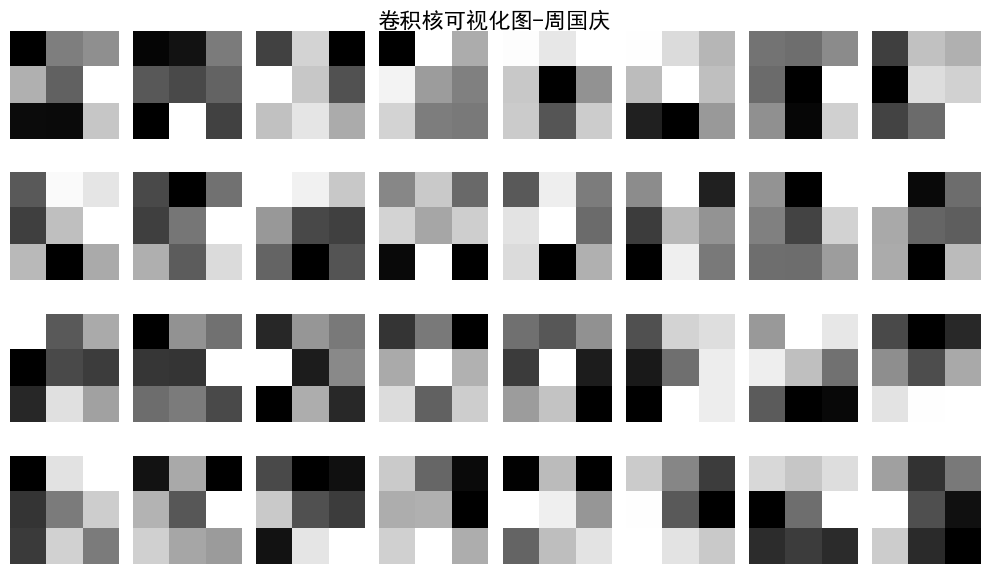

In [72]:
## Visualize first layer filters

weights = model.features[0].weight.data.cpu()

fig,axes = plt.subplots(
    4,
    8,
    figsize=(10,6)
)

for i,ax in enumerate(
    axes.flat
):

    ax.imshow(
        weights[i,0],
        cmap='gray'
    )

    ax.axis('off')

plt.tight_layout()

plt.suptitle("卷积核可视化图-周国庆", fontsize=16)

plt.show()

**卷积核可视化分析**

卷积核是CNN学习到的基础特征提取器。从可视化结果可以发现，不同卷积核关注不同方向的边缘和纹理结构。这些低层特征经过多层组合后，最终形成具有判别能力的高级语义特征，从而实现准确分类。

这一过程也是CNN显著优于传统机器学习模型的重要原因。

## 四、模型性能综合比较

完成所有模型训练后，需要从多个维度对模型进行综合评价。

评价维度包括：

- Accuracy
- Precision
- Recall
- F1-score
- Training Time

从而分析不同模型的优势与局限性。

In [67]:
result_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "准确率",
        "Precision",
        "Recall",
        "F1",
        "TrainTime"
    ]
)

result_df.sort_values(
    by="准确率",
    ascending=False
)

,Model,准确率,Precision,Recall,F1,TrainTime
5,CNN(PyTorch),0.9306,0.930954,0.9306,0.930041,95.712342
4,SVM(RBF),0.8945,0.893688,0.8945,0.893688,253.221931
3,Random Forest,0.8847,0.883346,0.8847,0.883023,6.380727
1,KNN,0.8589,0.861394,0.8589,0.858039,0.170658
0,Logistic Regression,0.8441,0.842634,0.8441,0.843136,41.924625
2,Decision Tree,0.8211,0.821579,0.8211,0.820515,17.732726


In [68]:
result_df

,Model,准确率,Precision,Recall,F1,TrainTime
0,Logistic Regression,0.8441,0.842634,0.8441,0.843136,41.924625
1,KNN,0.8589,0.861394,0.8589,0.858039,0.170658
2,Decision Tree,0.8211,0.821579,0.8211,0.820515,17.732726
3,Random Forest,0.8847,0.883346,0.8847,0.883023,6.380727
4,SVM(RBF),0.8945,0.893688,0.8945,0.893688,253.221931
5,CNN(PyTorch),0.9306,0.930954,0.9306,0.930041,95.712342


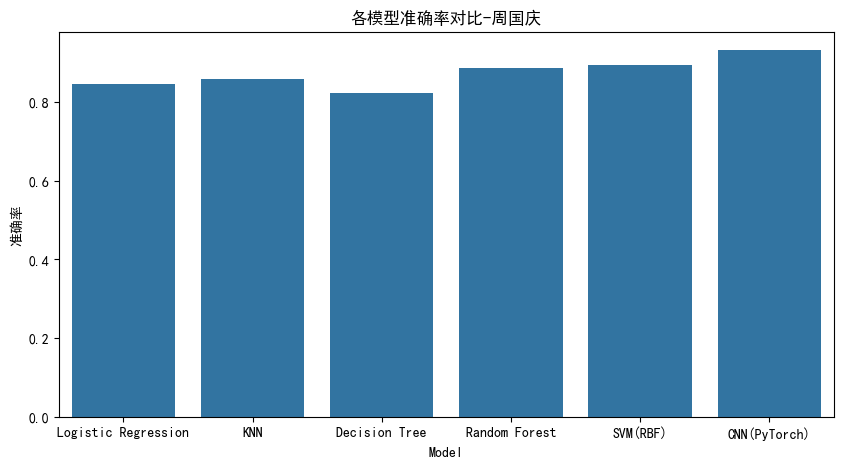

In [69]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=result_df,
    x="Model",
    y="准确率"
)

plt.title(
"各模型准确率对比-周国庆"
)

plt.show()

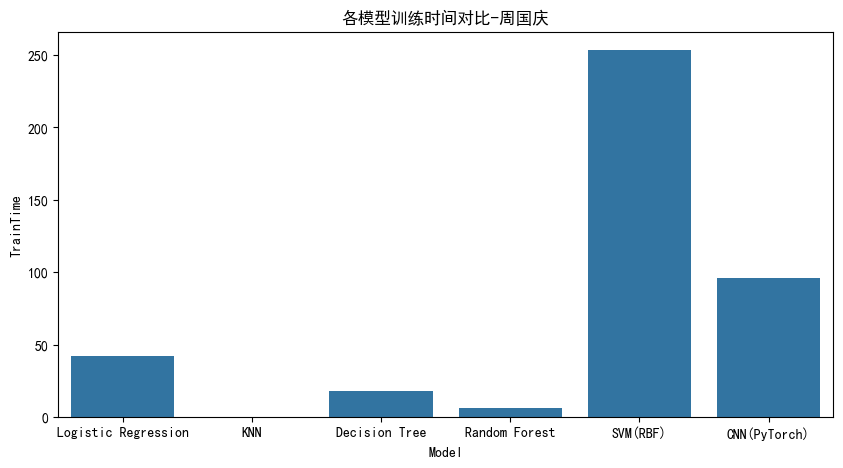

In [70]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=result_df,
    x="Model",
    y="TrainTime"
)

plt.title(
"各模型训练时间对比-周国庆"
)

plt.show()

SVM训练时间最长，这是因为SVM没有使用GPU，CNN使用GPU进行加速导致速度快了1-2个数量级，因此并不能说明SVM计算量比CNN大

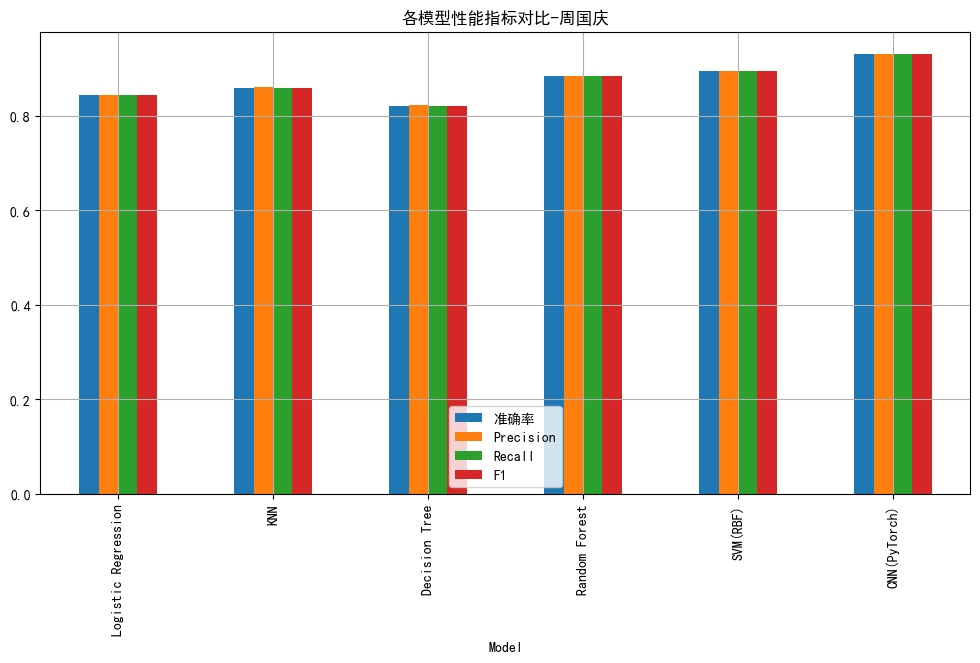

In [71]:
metrics = result_df.set_index(
    "Model"
)[[
    "准确率",
    "Precision",
    "Recall",
    "F1"
]]

metrics.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
"各模型性能指标对比-周国庆"
)

plt.grid()

plt.show()

### 4.1 综合结果分析

从实验结果可以发现，模型性能总体呈现以下规律：

CNN > SVM > Random Forest > KNN > Logistic Regression > Decision Tree

其中CNN取得最高Accuracy和F1-score，说明深度学习模型在图像分类任务上具有明显优势。

SVM是传统机器学习方法中表现最好的模型，说明最大间隔分类思想对于高维数据具有较强泛化能力。

Random Forest显著优于单棵Decision Tree，验证了集成学习能够有效提高模型稳定性。

KNN虽然表现优于Logistic Regression，但预测开销较大，在大规模数据集上存在明显局限性。

Logistic Regression训练速度最快，但由于线性模型表达能力有限，因此整体性能相对较低。